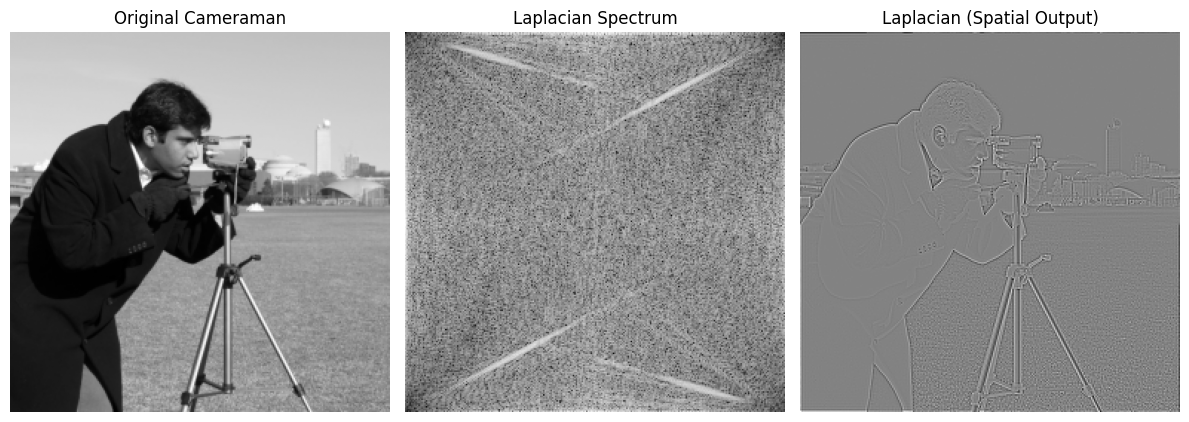

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# Load cameraman image (grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Optional resize

# Get image size
M, N = image.shape

# Generate frequency grid
u = np.fft.fftfreq(M).reshape(-1,1)
v = np.fft.fftfreq(N).reshape(1,-1)

# Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi**2) * (u**2 + v**2)

# Apply FFT
F = np.fft.fft2(image)

# Apply filter
F_lap = F * laplacian_filter

# Inverse FFT
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:


# Load and resize image
image = data.camera()
image = resize(image, (256,256))

# Sobel filters
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])

sobel_y = np.array([[-1,-2,-1],
                    [0,0,0],
                    [1,2,1]])

# Function to center kernel and take FFT
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    
    kh, kw = kernel.shape
    ph, pw = shape
    
    cy, cx = ph//2 , pw//2
    
    padded[cy-kh//2:cy-kh//2+kh,
           cx-kw//2:cx-kw//2+kw] = kernel
    
    return np.fft.fft2(np.fft.ifftshift(padded))

# FFT of image
F = np.fft.fft2(image)

# FFT of Sobel filters
Hx = center_embed_kernel(sobel_x, image.shape)
Hy = center_embed_kernel(sobel_y, image.shape)

# Apply filters in frequency domain
Fx = F * Hx
Fy = F * Hy

# Inverse FFT
sobel_x_img = np.fft.ifft2(Fx).real
sobel_y_img = np.fft.ifft2(Fy).real

# Gradient magnitude (combined result)
sobel_mag = np.sqrt(sobel_x_img**2 + sobel_y_img**2)

# Plot results
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(sobel_x_img, cmap='gray')
plt.title("Sobel X")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(sobel_y_img, cmap='gray')
plt.title("Sobel Y")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sobel_mag, cmap='gray')
plt.title("Sobel Magnitude")
plt.axis('off')

plt.tight_layout()
plt.show()